#Problem Statement 2:
---

An online retail store is trying to understand the various customer purchase patterns for their firm, you are required to give enough evidence based insights to provide the same.

1. Using the above data, find useful insights about the customer purchasing history
that can be an added advantage for the online retailer.
2. Segment the customers based on their purchasing behavior.

# **Import Required Libaraies**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.metrics import silhouette_score

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Project/ML/Capstone/OnlineRetail.csv" , encoding = 'latin1' , parse_dates=['InvoiceDate'])

In [ ]:
data.shape

(541909, 8)

In [ ]:
data.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [ ]:
data.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


“In this step, the dataset is explored to understand its structure, features, data types, and potential issues such as missing values or inconsistencies.”

# **Data Cleaning**

In [ ]:
data.isnull().sum().sum()

np.int64(136534)

In [ ]:
data[data.isnull().any(axis = 1)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,2011-12-09 10:26:00,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,2011-12-09 10:26:00,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,2011-12-09 10:26:00,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,2011-12-09 10:26:00,10.79,NaN,United Kingdom


“Although a significant portion of the dataset had missing CustomerID values, these records were removed because they cannot be linked to individual customers. Keeping them would negatively impact customer-level analysis and segmentation accuracy.”

In [ ]:
data_modify = data[data['CustomerID'].notnull()]
data_modify.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


In [ ]:
data_modify[data_modify['CustomerID'].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [ ]:
data_modify.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [ ]:
data_modify.duplicated().sum()

np.int64(5225)

In [ ]:
data_modify[data_modify.duplicated(keep = False)].sort_values(by = 'InvoiceNo')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
...,...,...,...,...,...,...,...,...
440149,C574510,22360,GLASS JAR ENGLISH CONFECTIONERY,-1,2011-11-04 13:25:00,2.95,15110.0,United Kingdom
461407,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,2011-11-13 11:38:00,0.55,17838.0,United Kingdom
461408,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,2011-11-13 11:38:00,0.55,17838.0,United Kingdom
529981,C580764,22667,RECIPE BOX RETROSPOT,-12,2011-12-06 10:38:00,2.95,14562.0,United Kingdom


In [ ]:
data_modify.drop_duplicates(inplace = True)

/tmp/ipykernel_3859/1949514725.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
data_modify.duplicated().sum()

np.int64(0)

In [ ]:
data_modify.shape

(401604, 8)

“Transactions with non-positive quantity and price were removed to ensure accurate calculation of customer spending and purchasing behavior.”

“Returned transactions were excluded as they represent reverse flows and can distort customer purchase frequency and monetary value, which are critical for accurate segmentation.”

“Although zero-priced items may represent promotional or free products, they were excluded to ensure that frequency and monetary metrics reflect actual purchasing behavior and spending capacity of customers.”

In [ ]:
data_modify[(data_modify['Description'] == 'Manual') | (data_modify['StockCode'] == 'M')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2239,536569,M,Manual,1,2010-12-01 15:35:00,1.25,16274.0,United Kingdom
2250,536569,M,Manual,1,2010-12-01 15:35:00,18.95,16274.0,United Kingdom
6798,536981,M,Manual,2,2010-12-03 14:26:00,0.85,14723.0,United Kingdom
7976,537077,M,Manual,12,2010-12-05 11:59:00,0.42,17062.0,United Kingdom
8530,537137,M,Manual,36,2010-12-05 12:43:00,0.85,16327.0,United Kingdom
...,...,...,...,...,...,...,...,...
531432,580956,M,Manual,4,2011-12-06 14:23:00,1.25,17841.0,United Kingdom
533082,C581009,M,Manual,-1,2011-12-07 09:15:00,125.00,16971.0,United Kingdom
534308,C581145,M,Manual,-1,2011-12-07 13:48:00,9.95,17490.0,United Kingdom
538321,581405,M,Manual,3,2011-12-08 13:50:00,0.42,13521.0,United Kingdom


In [ ]:
data_modify = data_modify[(data_modify['Description'] != 'Manual') | (data_modify['StockCode'] != 'M')]

In [ ]:
data_modify.shape

(401144, 8)

In [ ]:
data_modify = data_modify[data_modify['Quantity'] > 0]

In [ ]:
data_modify = data_modify[data_modify['UnitPrice'] > 0]

In [ ]:
data_modify.shape

(392413, 8)

In [ ]:
for i in data_modify.columns:
  print('*'*25)
  print(data_modify[i].value_counts())

*************************
InvoiceNo
576339    542
579196    533
580727    529
578270    442
573576    435
         ... 
543016      1
542992      1
542892      1
578311      1
542926      1
Name: count, Length: 18468, dtype: int64
*************************
StockCode
85123A    2023
22423     1713
85099B    1615
84879     1395
47566     1389
          ... 
84206B       1
90212B       1
35597B       1
84613C       1
84802A       1
Name: count, Length: 3664, dtype: int64
*************************
Description
WHITE HANGING HEART T-LIGHT HOLDER    2016
REGENCY CAKESTAND 3 TIER              1713
JUMBO BAG RED RETROSPOT               1615
ASSORTED COLOUR BIRD ORNAMENT         1395
PARTY BUNTING                         1389
                                      ... 
AMBER BERTIE GLASS BEAD BAG CHARM        1
BAROQUE BUTTERFLY EARRINGS CRYSTAL       1
ROCOCO WALL MIROR                        1
CROCHET LILAC/RED BEAR KEYRING           1
PAPER CRAFT , LITTLE BIRDIE              1
Name: count, Leng

In [ ]:
data_modify.head(4)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# **Customer behavior**

In [ ]:
data_modify['LineTotal'] = data_modify['Quantity'] * data_modify['UnitPrice']

In [ ]:
snapshot_date = data_modify['InvoiceDate'].max() + pd.Timedelta(days=1)
recency = data_modify.groupby('CustomerID')['InvoiceDate'].max().reset_index()
recency['Recency'] = (snapshot_date - recency['InvoiceDate']).dt.days
recency = recency[['CustomerID', 'Recency']]

In [ ]:
recency.set_index('CustomerID' , inplace = True)

In [ ]:
Customer_level = recency

In [ ]:
Customer_level['Frequency'] = data_modify.groupby(['CustomerID'])['InvoiceNo'].nunique()
Customer_level['Monetary'] = data_modify.groupby(['CustomerID'])['LineTotal'].sum()

In [ ]:
result = data_modify.groupby(['InvoiceNo', 'CustomerID'])['LineTotal'].sum().reset_index()

In [ ]:
aov = result.groupby('CustomerID').agg({
    'LineTotal': 'sum',
    'InvoiceNo': 'count'
}).reset_index()

aov['AOV'] = aov['LineTotal'] / aov['InvoiceNo']

In [ ]:
aov.set_index('CustomerID' , inplace = True)

In [ ]:
Customer_level = Customer_level.join(aov['AOV'])

In [ ]:
Customer_level.reset_index(inplace = True)

In [ ]:
Customer_level.head()

,CustomerID,Recency,Frequency,Monetary,AOV
0,12346.0,326,1,77183.60,77183.600000
1,12347.0,2,7,4310.00,615.714286
2,12348.0,75,4,1797.24,449.310000
3,12349.0,19,1,1757.55,1757.550000
4,12350.0,310,1,334.40,334.400000


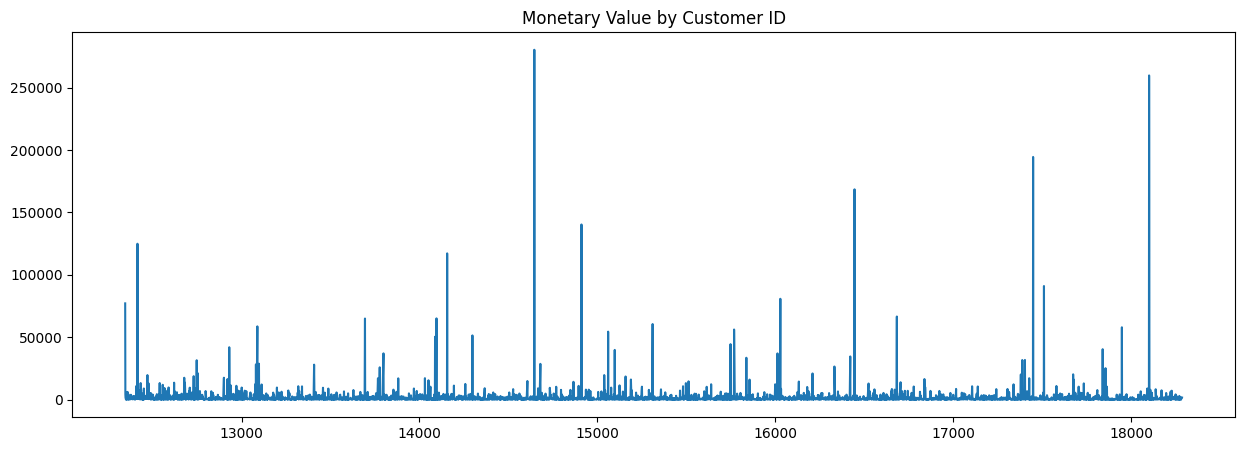

In [ ]:
plt.figure(figsize = (15,5))
plt.plot(Customer_level['CustomerID'] , Customer_level['Monetary'])
plt.title('Monetary Value by Customer ID')
plt.show()

In [ ]:
fig = px.line(Customer_level,
              x='CustomerID',
              y=['Monetary' , 'Frequency' ,'Recency'],
              title='Monetary Value by Customer ID')

fig.show()

In [ ]:
Customer_level.head(3)

,CustomerID,Recency,Frequency,Monetary,AOV
0,12346.0,326,1,77183.60,77183.600000
1,12347.0,2,7,4310.00,615.714286
2,12348.0,75,4,1797.24,449.310000


In [ ]:
Customer_level.describe()

,CustomerID,Recency,Frequency,Monetary,AOV
count,4335.000000,4335.000000,4335.000000,4335.000000,4335.000000
mean,15299.372549,92.678662,4.260208,2037.782921,417.438540
std,1721.813812,100.203903,7.659946,8966.232704,1797.164715
min,12346.000000,1.000000,1.000000,3.750000,3.750000
25%,13812.500000,18.000000,1.000000,306.290000,177.821161
50%,15298.000000,51.000000,2.000000,668.560000,291.620000
75%,16778.500000,143.000000,5.000000,1651.605000,428.109583
max,18287.000000,374.000000,206.000000,280206.020000,84236.250000


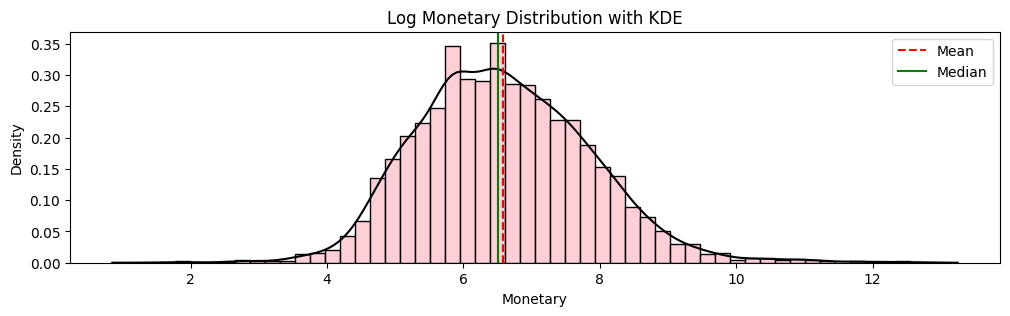

In [ ]:
plt.figure(figsize = (12,3))
sns.histplot(np.log1p(Customer_level['Monetary']), bins=50, color='pink' , stat='density')

sns.kdeplot(np.log1p(Customer_level['Monetary']), color='black', linewidth=1.5)

plt.axvline(np.log1p(Customer_level['Monetary']).mean(), linestyle='dashed', color='red', label='Mean')
plt.axvline(np.median(np.log1p(Customer_level['Monetary'])), linestyle='solid', color='green', label='Median')

plt.legend()
plt.title("Log Monetary Distribution with KDE")
plt.show()

***Insight 1: Customer Spending Distribution***

**Observation:**

The monetary distribution is right-skewed, where most customers have low to moderate spending, while a small number of customers exhibit very high spending behavior.

**Business Insight:**

This indicates that a small segment of high-value customers contributes significantly to total revenue, while the majority of customers generate lower revenue. Therefore, the business should focus on retaining high-value customers and increasing the spending of low-value customers through targeted marketing and upselling strategies.

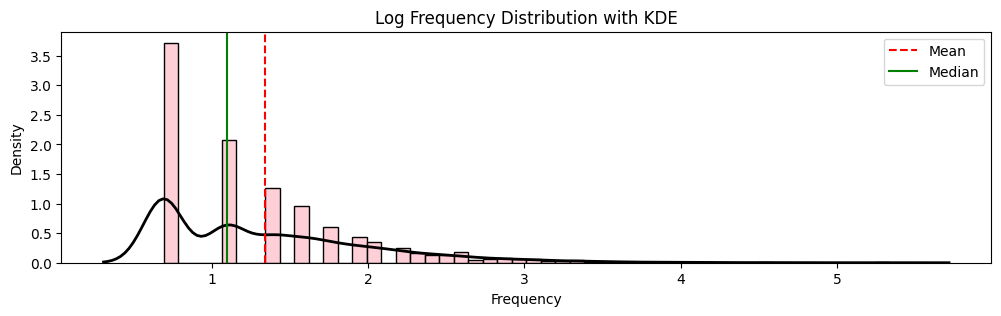

In [ ]:
plt.figure(figsize = (12,3))
sns.histplot(np.log1p(Customer_level['Frequency']), bins=50, color='pink' , stat='density')

sns.kdeplot(np.log1p(Customer_level['Frequency']), color='black', linewidth=2)

plt.axvline(np.log1p(Customer_level['Frequency']).mean(), linestyle='dashed', color='red', label='Mean')
plt.axvline(np.median(np.log1p(Customer_level['Frequency'])), linestyle='solid', color='green', label='Median')

plt.legend()
plt.title("Log Frequency Distribution with KDE")
plt.show()

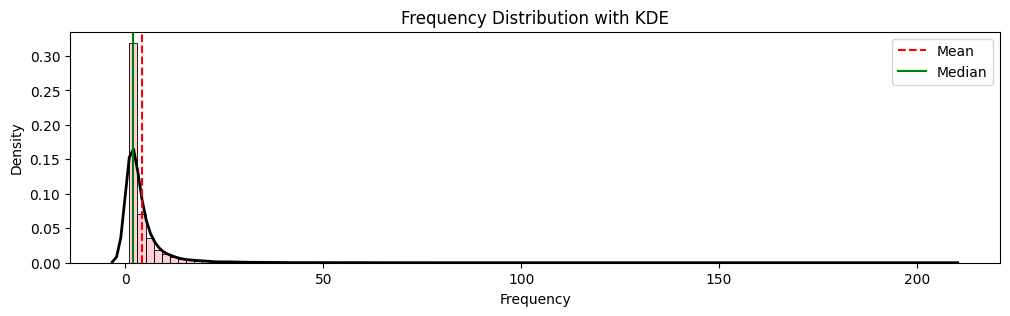

In [ ]:
plt.figure(figsize = (12,3))
sns.histplot(Customer_level['Frequency'], bins=100, color='pink' , stat='density')

sns.kdeplot(Customer_level['Frequency'], color='black', linewidth=2)

plt.axvline(Customer_level['Frequency'].mean(), linestyle='dashed', color='red', label='Mean')
plt.axvline(np.median(Customer_level['Frequency']), linestyle='solid', color='green', label='Median')

plt.legend()
plt.title("Frequency Distribution with KDE")
plt.show()

***Insight2: Customer Purchase Frequency Behavior***

**Observation:**

The frequency distribution is highly right-skewed, with most customers having very low purchase frequency (clustered near 1–2 orders), while a small number of customers exhibit extremely high purchase frequency, forming a long tail. The mean lies to the right of the median, confirming the presence of high-frequency outliers.

**Business Insight:**

This indicates that the majority of customers are one-time or occasional buyers, whereas a small segment represents highly loyal customers who make repeated purchases. The business should focus on increasing customer retention and encouraging repeat purchases through loyalty programs and personalized marketing strategies.

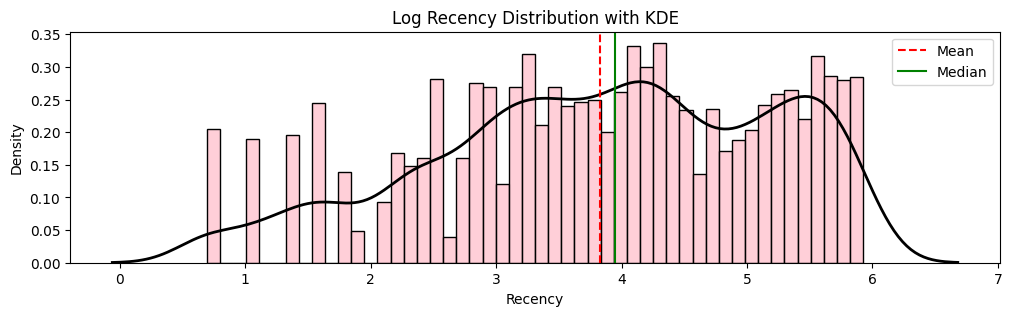

In [ ]:
plt.figure(figsize = (12,3))
sns.histplot(np.log1p(Customer_level['Recency']), bins=50, color='pink' , stat='density')

sns.kdeplot(np.log1p(Customer_level['Recency']), color='black', linewidth=2)

plt.axvline(np.log1p(Customer_level['Recency']).mean(), linestyle='dashed', color='red', label='Mean')
plt.axvline(np.median(np.log1p(Customer_level['Recency'])), linestyle='solid', color='green', label='Median')

plt.legend()
plt.title("Log Recency Distribution with KDE")
plt.show()

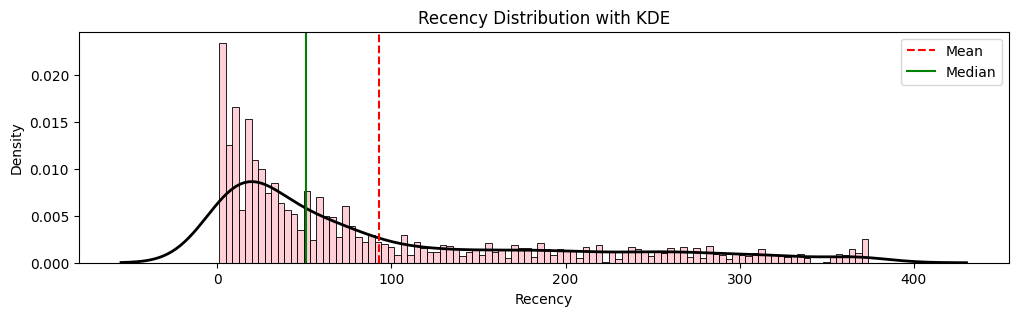

In [ ]:
plt.figure(figsize = (12,3))
sns.histplot(Customer_level['Recency'], bins=100, color='pink' , stat='density')

sns.kdeplot(Customer_level['Recency'], color='black', linewidth=2)

plt.axvline(Customer_level['Recency'].mean(), linestyle='dashed', color='red', label='Mean')
plt.axvline(np.median(Customer_level['Recency']), linestyle='solid', color='green', label='Median')

plt.legend()
plt.title("Recency Distribution with KDE")
plt.show()

***Insight 3: Customer Activity (Recency)***

**Observation:**

The recency distribution is right-skewed, where a significant number of customers have low recency values (recent purchases), while a large portion of customers have high recency values, indicating they have not made purchases for a long time. The mean is higher than the median, showing the presence of inactive customers.

**Business Insight:**

This indicates that while some customers are actively engaging with the business, a large segment of customers has become inactive or at risk of churn. The business should focus on re-engagement strategies such as targeted promotions, reminders, and personalized offers to bring back inactive customers.


---


***Insight 4: Loyal High-Value Customers***

**Observation:**

Customers with low recency (recent purchases) and high frequency tend to also have high monetary value.

**Business Insight:**

These customers represent loyal and high-value segments who contribute significantly to revenue through repeated purchases. The business should prioritize retaining these customers through loyalty programs, exclusive offers, and personalized engagement strategies.


---


***Insight 5: At-Risk / Lost Customers***

**Observation:**

Customers with high recency (long inactivity) and low frequency generally exhibit low monetary value.

**Business Insight:**

These customers are either at risk of churn or already inactive, contributing minimally to revenue. The business should focus on reactivation strategies such as targeted discounts, reminder campaigns, and personalized outreach to bring them back.



---


***Insight 6: Upsell Opportunity Customers***

**Observation:**

Some customers show high frequency but relatively moderate monetary value.

**Business Insight:**

These customers are engaged but spend less per transaction, indicating an opportunity for upselling and cross-selling to increase their overall value.

In [ ]:
Customer_level.head()

,CustomerID,Recency,Frequency,Monetary,AOV
0,12346.0,326,1,77183.60,77183.600000
1,12347.0,2,7,4310.00,615.714286
2,12348.0,75,4,1797.24,449.310000
3,12349.0,19,1,1757.55,1757.550000
4,12350.0,310,1,334.40,334.400000


In [ ]:
top_freq = Customer_level.sort_values(by='Frequency', ascending=False).head(10)
print('Top 10 Frequent Customer are - ')
print(top_freq[['CustomerID' , 'Frequency']])

Top 10 Frequent Customer are - 
      CustomerID  Frequency
326      12748.0        206
1879     14911.0        199
4008     17841.0        124
562      13089.0         97
1661     14606.0         92
2176     15311.0         91
481      12971.0         86
1689     14646.0         73
2701     16029.0         63
795      13408.0         62


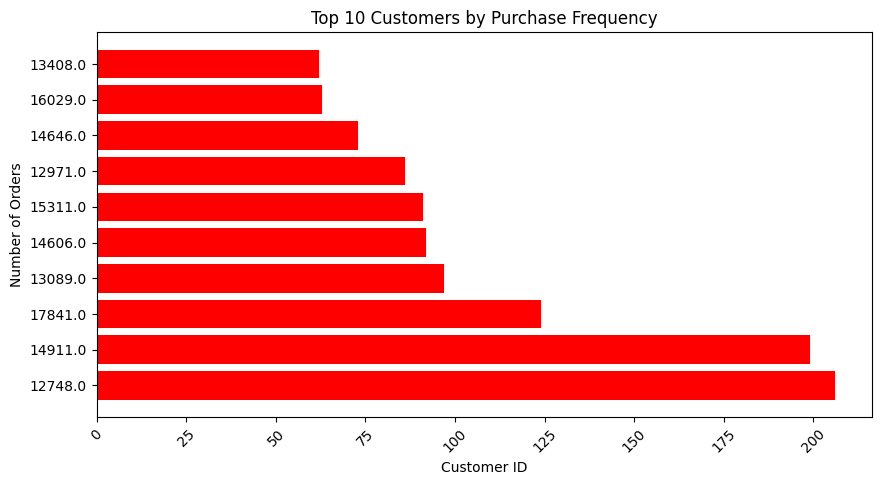

In [ ]:
plt.figure(figsize=(10,5))

plt.barh(top_freq['CustomerID'].astype(str) , top_freq['Frequency'] , color = 'red')
plt.title("Top 10 Customers by Purchase Frequency")
plt.xlabel("Customer ID")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.show()

**Observation:**
A small group of customers has significantly higher purchase frequency compared to others.

**Business Insight:**
These customers are highly loyal and should be targeted with retention strategies such as loyalty programs and exclusive offers.

In [ ]:
top_spend = Customer_level.sort_values(by = 'Monetary' , ascending = False).head(10)
print('Top 10 Monetary Customer are - ')
print(top_spend[['CustomerID' , 'Monetary']])

Top 10 Monetary Customer are - 
      CustomerID   Monetary
1689     14646.0  280206.02
4198     18102.0  259657.30
3726     17450.0  194390.79
3007     16446.0  168472.50
1879     14911.0  140336.83
55       12415.0  124914.53
1333     14156.0  117210.08
3769     17511.0   91062.38
2701     16029.0   80850.84
0        12346.0   77183.60


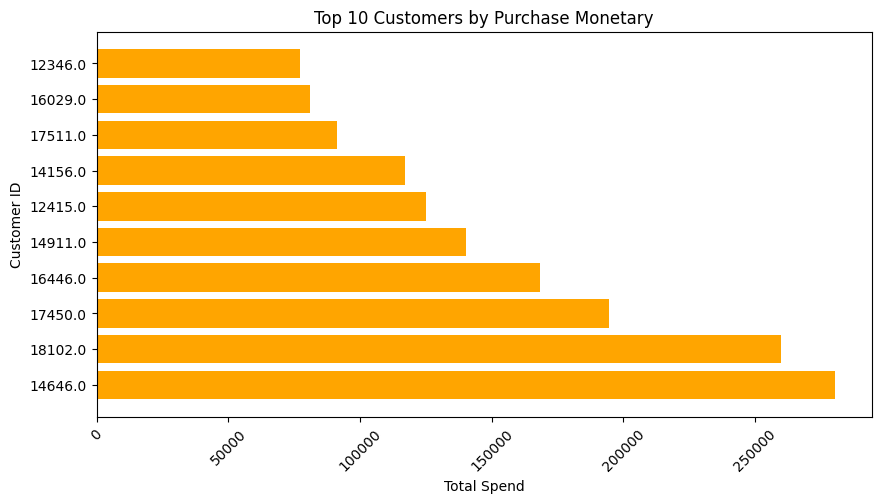

In [ ]:
plt.figure(figsize=(10,5))

plt.barh(top_spend['CustomerID'].astype(str) , top_spend['Monetary'] , color = 'orange')
plt.title("Top 10 Customers by Purchase Monetary")
plt.xlabel("Total Spend")
plt.ylabel("Customer ID")

plt.xticks(rotation=45)
plt.show()

In [ ]:
top_aov = Customer_level.sort_values(by = 'AOV' , ascending = False).head(10)
print('Top 10 Average order value Customer are - ')
print(top_aov[['CustomerID' , 'AOV']])

Top 10 Average order value Customer are - 
      CustomerID           AOV
3007     16446.0  84236.250000
0        12346.0  77183.600000
2502     15749.0  14844.766667
2011     15098.0  13305.500000
10       12357.0   6207.670000
55       12415.0   5948.310952
196      12590.0   4932.130000
278      12688.0   4873.810000
329      12752.0   4366.780000
4198     18102.0   4327.621667


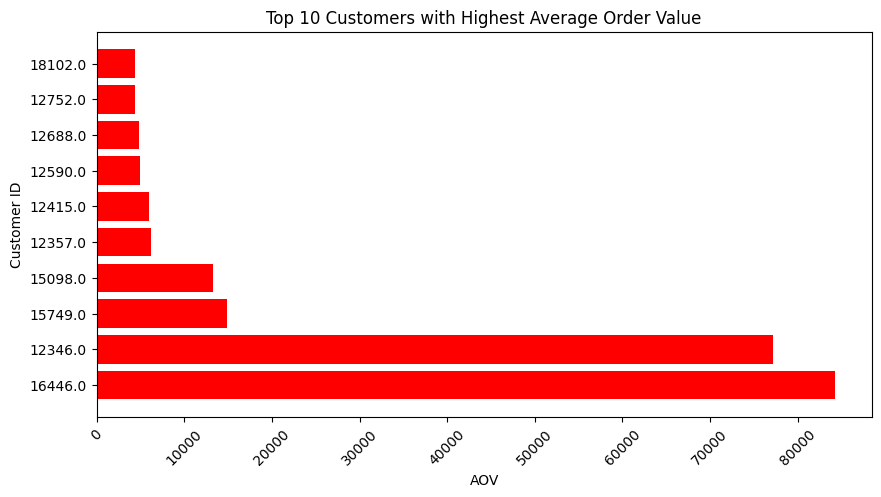

In [ ]:
plt.figure(figsize=(10,5))

plt.barh(top_aov['CustomerID'].astype(str) , top_aov['AOV'] , color = 'red')
plt.title("Top 10 Customers with Highest Average Order Value")
plt.xlabel("AOV")
plt.ylabel("Customer ID")

plt.xticks(rotation=45)
plt.show()

**Observation:**
A small number of customers exhibit extremely high average order values, significantly higher than the rest of the customer base.

**Business Insight:**
This indicates the presence of premium or bulk buyers who place high-value orders. However, further analysis of their purchase frequency is required to distinguish between one-time bulk buyers and consistently high-value customers. The business can target such customers with premium offerings and personalized deals.

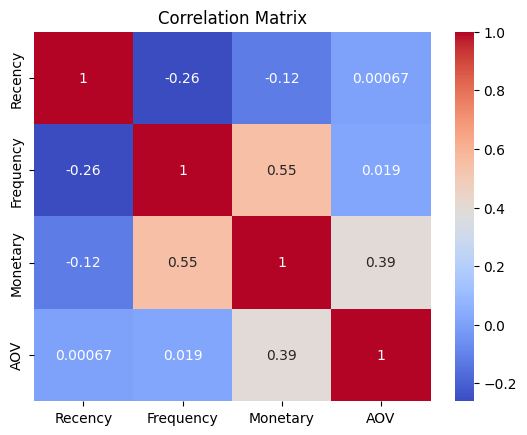

In [ ]:
corr = Customer_level[['Recency', 'Frequency', 'Monetary', 'AOV']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

***Insight: Correlation Analysis of Customer Behavior***

**Observation:**

**Frequency vs Monetary (0.55):**
This is the strongest positive correlation, indicating that customers who purchase more frequently tend to contribute significantly higher total revenue.

**Monetary vs AOV (0.39):**
A moderate positive relationship suggests that higher spending is partly driven by larger order values, not just purchase frequency.

**Recency vs Frequency (-0.26):**
A negative correlation indicates that customers who purchased recently (low recency) tend to buy more frequently, highlighting active engagement.



---


**Business Insight & Strategy:**

**Revenue Growth Driver:**
Since Frequency has the strongest impact on Monetary value, increasing customer purchase frequency is a key driver for revenue growth.

**Customer Retention Signal:**
Recency acts as an early warning indicator—customers with increasing recency are likely to reduce their purchase frequency.
→ Action: Implement timely re-engagement campaigns to prevent churn.

**Customer Segmentation Strategy:**
The weak relationship between AOV and Frequency highlights two distinct customer segments:

**Loyal Customers:** High Frequency, Low AOV → frequent but smaller purchases
Premium Customers: Low Frequency, High AOV → infrequent but high-value purchases

**→ Strategy:**

Upsell and bundle offers for loyal customers
Increase engagement frequency for premium customers through targeted campaigns



---



# **Product behavior**

In [ ]:
data_modify.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,LineTotal
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


**A. Most Frequent Items**

In [ ]:
items_freq = data_modify['Description'].value_counts().sort_values(ascending = False).reset_index()
print('Top 10 Most Frequently Sold Items:')
print(items_freq.head(10))

Top 10 Most Frequently Sold Items:
                          Description  count
0  WHITE HANGING HEART T-LIGHT HOLDER   2016
1            REGENCY CAKESTAND 3 TIER   1713
2             JUMBO BAG RED RETROSPOT   1615
3       ASSORTED COLOUR BIRD ORNAMENT   1395
4                       PARTY BUNTING   1389
5             LUNCH BAG RED RETROSPOT   1303
6   SET OF 3 CAKE TINS PANTRY DESIGN    1152
7                             POSTAGE   1099
8             LUNCH BAG  BLACK SKULL.   1078
9     PACK OF 72 RETROSPOT CAKE CASES   1050


In [ ]:
items_freq.head(10)

,Description,count
0,WHITE HANGING HEART T-LIGHT HOLDER,2016
1,REGENCY CAKESTAND 3 TIER,1713
2,JUMBO BAG RED RETROSPOT,1615
3,ASSORTED COLOUR BIRD ORNAMENT,1395
4,PARTY BUNTING,1389
5,LUNCH BAG RED RETROSPOT,1303
6,SET OF 3 CAKE TINS PANTRY DESIGN,1152
7,POSTAGE,1099
8,LUNCH BAG BLACK SKULL.,1078
9,PACK OF 72 RETROSPOT CAKE CASES,1050


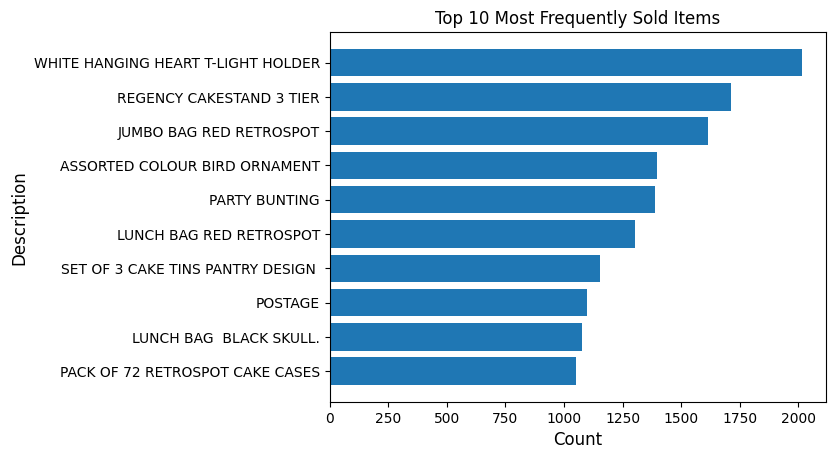

In [ ]:
plt.barh(items_freq['Description'].head(10) , items_freq['count'].head(10))
plt.xlabel('Count', fontsize=12)
plt.ylabel('Description', fontsize=12)
plt.gca().invert_yaxis()
plt.title('Top 10 Most Frequently Sold Items')
plt.show()

**Observation:**

A small set of products appears very frequently across transactions, indicating consistent and repeated demand. These items are typically low-cost and commonly used products.

**Business Insight:**

These products act as high-demand or staple items and should be prioritized for:
1.   Inventory availability
2.   Regular restocking
3.   Promotional bundling

They can also be used as entry-point products to attract customers.

**B. Most Sold Items**

In [ ]:
items = data_modify.groupby('Description')['Quantity'].sum().sort_values(ascending = False).reset_index()
print(f'Top 10 item most sold items (by quantity): \n {items.head(10)}')

Top 10 item most sold items (by quantity): 
                           Description  Quantity
0         PAPER CRAFT , LITTLE BIRDIE     80995
1      MEDIUM CERAMIC TOP STORAGE JAR     77916
2   WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
3             JUMBO BAG RED RETROSPOT     46078
4  WHITE HANGING HEART T-LIGHT HOLDER     36706
5       ASSORTED COLOUR BIRD ORNAMENT     35263
6     PACK OF 72 RETROSPOT CAKE CASES     33670
7                      POPCORN HOLDER     30919
8                  RABBIT NIGHT LIGHT     27153
9             MINI PAINT SET VINTAGE      26076


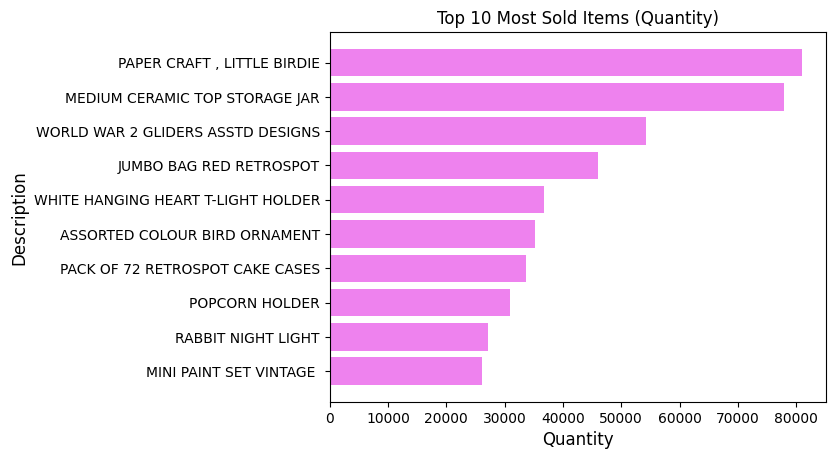

In [ ]:
plt.barh(items['Description'].head(10) , items['Quantity'].head(10) ,  color = 'violet')
plt.xlabel('Quantity', fontsize=12)
plt.ylabel('Description', fontsize=12)
plt.gca().invert_yaxis()
plt.title('Top 10 Most Sold Items (Quantity)')
plt.show()

**Observation:**

Certain products dominate in terms of total quantity sold, suggesting that customers purchase them in bulk or repeatedly.

**Business Insight:**

These items indicate volume-driven sales, and the business should:
1.   Ensure continuous stock availability
2.   Optimize supply chain for these products
3.   Consider bulk discounts to further increase sales




**C. Top Revenue Items**

In [ ]:
frequent_items = data_modify.groupby('Description')['LineTotal'].sum().sort_values(ascending = False).reset_index()
print(f'Top 10 item most sold items \n {frequent_items.head(10)}')

Top 10 item most sold items 
                           Description  LineTotal
0         PAPER CRAFT , LITTLE BIRDIE  168469.60
1            REGENCY CAKESTAND 3 TIER  142264.75
2  WHITE HANGING HEART T-LIGHT HOLDER  100392.10
3             JUMBO BAG RED RETROSPOT   85040.54
4      MEDIUM CERAMIC TOP STORAGE JAR   81416.73
5                             POSTAGE   77803.96
6                       PARTY BUNTING   68785.23
7       ASSORTED COLOUR BIRD ORNAMENT   56413.03
8                  RABBIT NIGHT LIGHT   51251.24
9                       CHILLI LIGHTS   46265.11


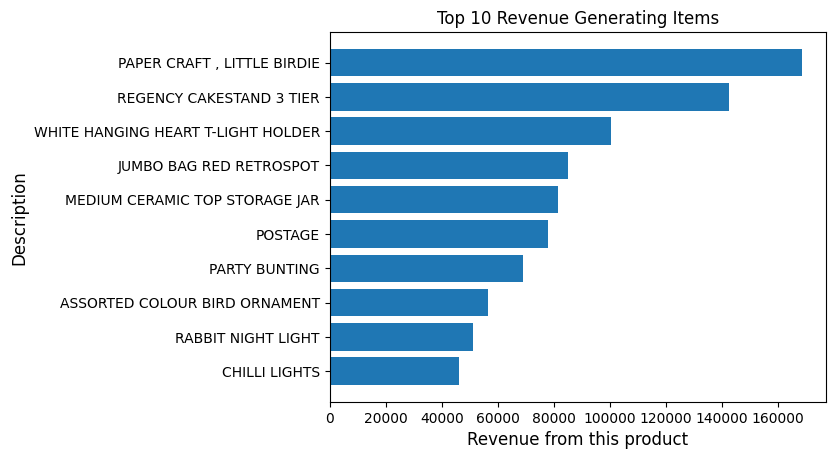

In [ ]:
plt.barh(frequent_items['Description'].head(10) , frequent_items['LineTotal'].head(10))
plt.xlabel('Revenue from this product', fontsize=12)
plt.ylabel('Description', fontsize=12)
plt.gca().invert_yaxis()
plt.title('Top 10 Revenue Generating Items')
plt.show()

**Observation:**

A limited number of products contribute significantly to total revenue. These include both premium items and high-demand products. Additionally, non-product entries like postage also appear among top contributors.

**Business Insight:**

These products are key revenue drivers and should be:



*   Highlighted in marketing campaigns
*   Featured prominently on the platform


Non-product entries (like postage) should be excluded for accurate product-level analysis.

***Product Demand vs Revenue Pattern***

Observation:

High-frequency or high-quantity products are not always the highest revenue generators, indicating a distinction between popular items and high-value items.

**Business Insight:**

This reveals two types of products:



1.   Popular Products: High frequency, low price → drive volume
2.   Premium Products: Low frequency, high price → drive revenue



👉 Strategy:



1.   Use bundling & cross-selling to increase value of popular items
2.   Promote premium products to high-value customers







Product behavior analysis reveals a clear distinction between high-demand, low-value items and low-demand, high-value items, highlighting the need for differentiated marketing and inventory strategies.

# **Geographic analysis**

In [ ]:
country = data_modify.groupby('Country')['InvoiceNo'].count().sort_values(ascending = False).reset_index()
country['Count'] = country['InvoiceNo']
country.drop('InvoiceNo' , axis = 1 , inplace = True)

In [ ]:
country

,Country,Count
0,United Kingdom,348960
1,Germany,9017
2,France,8321
3,EIRE,7224
4,Spain,2479
5,Netherlands,2359
6,Belgium,2031
7,Switzerland,1841
8,Portugal,1446
9,Australia,1181


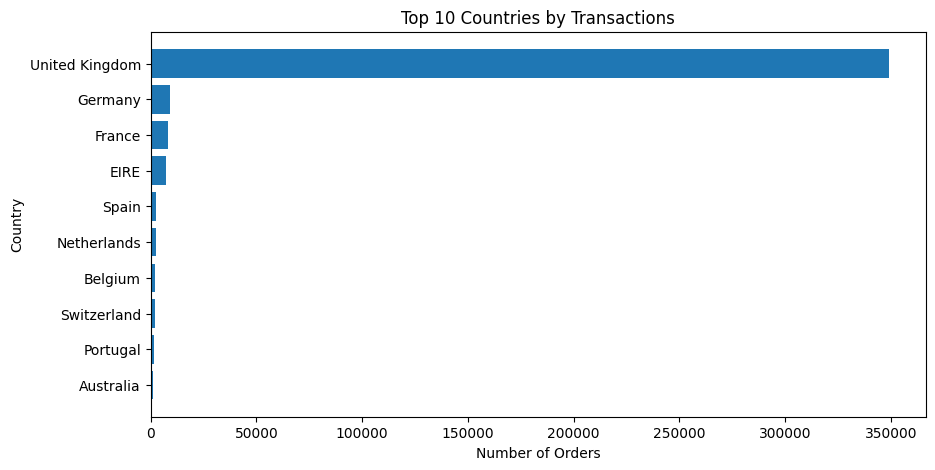

In [ ]:
plt.figure(figsize=(10,5))
plt.barh(country.head(10)['Country'], country.head(10)['Count'])
plt.title("Top 10 Countries by Transactions")
plt.xlabel("Number of Orders")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
RFM = Customer_level.drop(['AOV'] , axis = 1)

In [ ]:
RFM.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


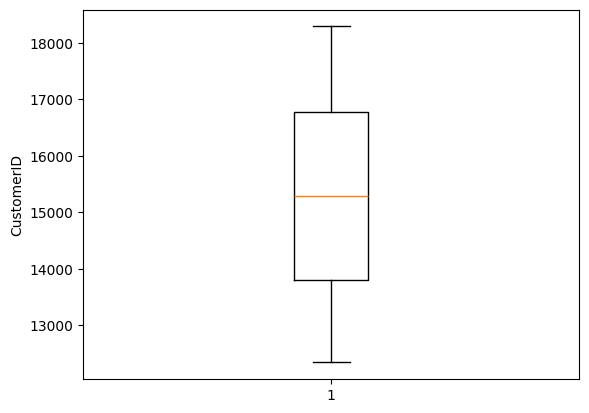

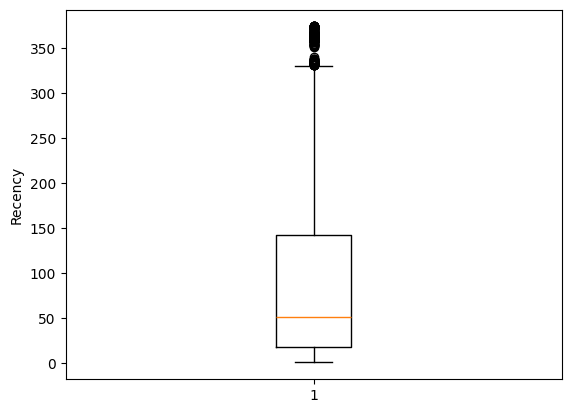

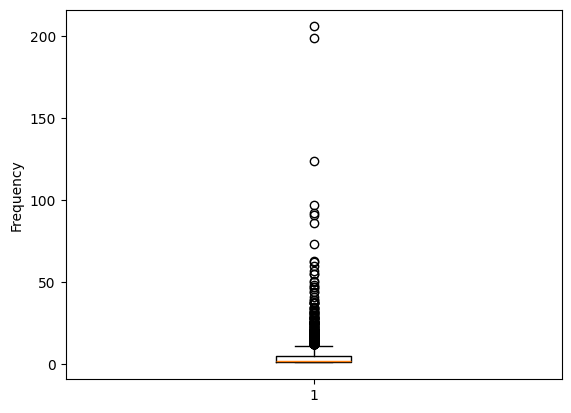

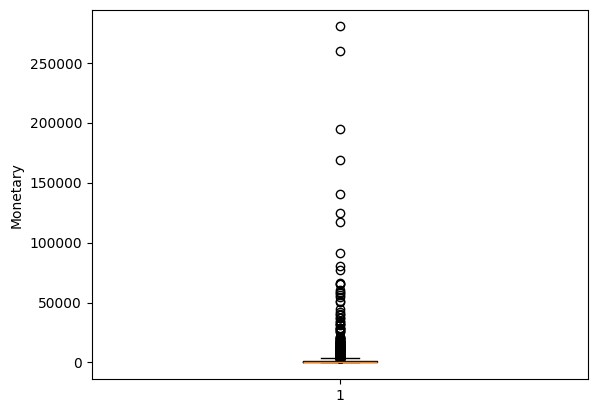

In [ ]:
for i in RFM.columns:
  plt.boxplot(RFM[i])
  plt.ylabel(i)
  plt.show()

In [ ]:
RFM['Monetary'] = np.log1p(RFM['Monetary'])
RFM['Frequency'] = np.log1p(RFM['Frequency'])
RFM['Recency'] = np.log1p(RFM['Recency'])

In [ ]:
RFM

,CustomerID,Recency,Frequency,Monetary
0,12346.0,5.789960,0.693147,11.253955
1,12347.0,1.098612,2.079442,8.368925
2,12348.0,4.330733,1.609438,7.494564
3,12349.0,2.995732,0.693147,7.472245
4,12350.0,5.739793,0.693147,5.815324
...,...,...,...,...
4330,18280.0,5.631212,0.693147,5.201806
4331,18281.0,5.204007,0.693147,4.404522
4332,18282.0,2.197225,1.098612,5.187665
4333,18283.0,1.609438,2.833213,7.620989


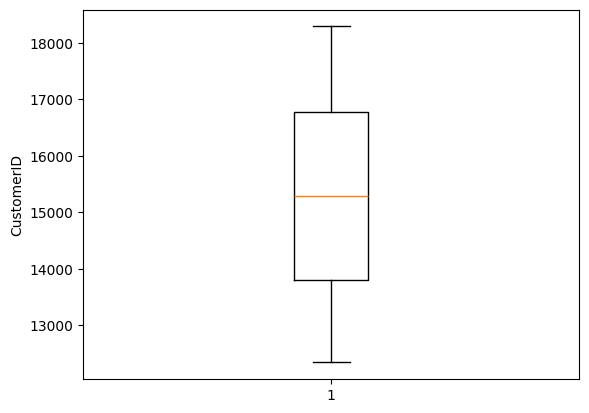

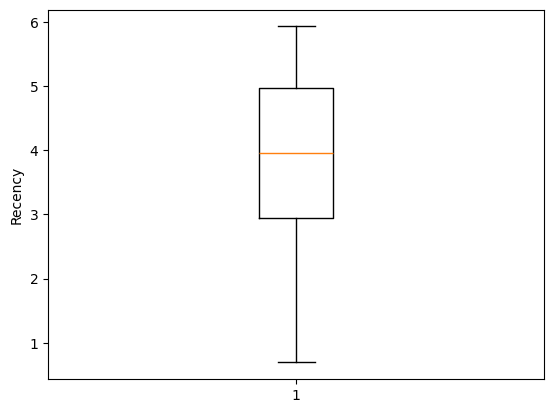

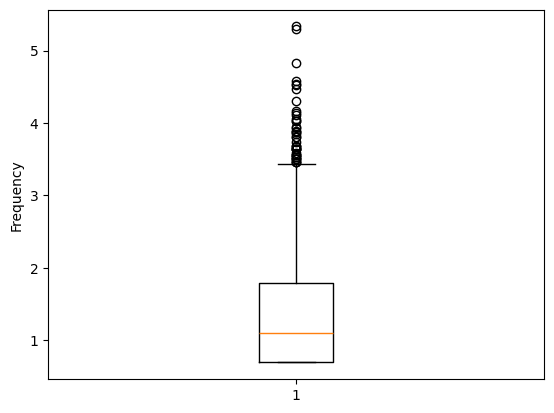

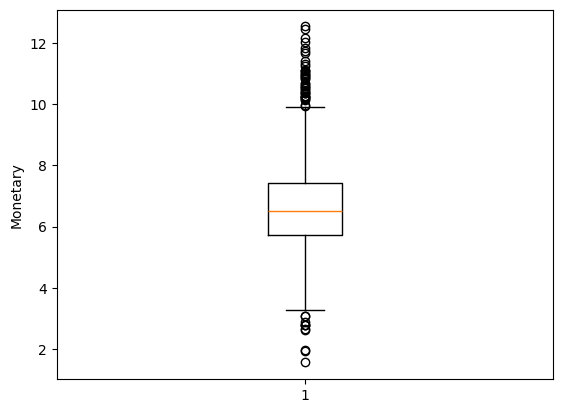

In [ ]:
for i in RFM.columns:
  plt.boxplot(RFM[i])
  plt.ylabel(i)
  plt.show()

In [ ]:
from sklearn.preprocessing import RobustScaler

In [ ]:
rs = RobustScaler()
rfm_scaled = rs.fit_transform(RFM[['Recency', 'Frequency', 'Monetary']])

In [ ]:
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
model = KMeans(n_clusters = 4 , random_state = 42)
rfm_scaled['Cluster'] = model.fit_predict(rfm_scaled)

In [ ]:
RFM['Cluster'] = rfm_scaled['Cluster']

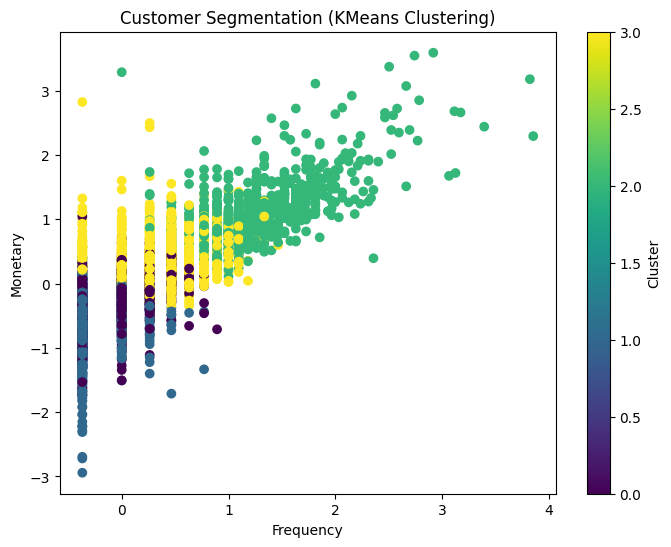

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(rfm_scaled['Frequency'],
            rfm_scaled['Monetary'],
            c=rfm_scaled['Cluster'],
            cmap='viridis')

plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Segmentation (KMeans Clustering)")

plt.colorbar(label='Cluster')
plt.show()

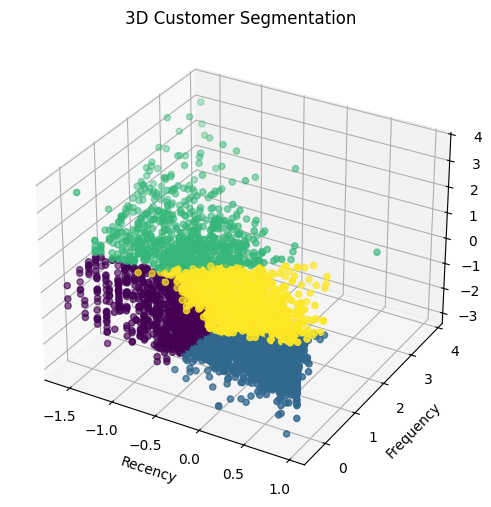

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(rfm_scaled['Recency'],
           rfm_scaled['Frequency'],
           rfm_scaled['Monetary'],
           c=rfm_scaled['Cluster'], cmap='viridis')

ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")

plt.title("3D Customer Segmentation")
plt.show()

In [ ]:
import plotly.express as px

fig = px.scatter_3d(
    RFM,
    x='Recency',
    y='Frequency',
    z='Monetary',
    color='Cluster',
    title='3D Customer Segmentation'
)

fig.show()

In [ ]:
RFM

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,5.789960,0.693147,11.253955,3
1,12347.0,1.098612,2.079442,8.368925,2
2,12348.0,4.330733,1.609438,7.494564,3
3,12349.0,2.995732,0.693147,7.472245,0
4,12350.0,5.739793,0.693147,5.815324,1
...,...,...,...,...,...
4330,18280.0,5.631212,0.693147,5.201806,1
4331,18281.0,5.204007,0.693147,4.404522,1
4332,18282.0,2.197225,1.098612,5.187665,0
4333,18283.0,1.609438,2.833213,7.620989,2


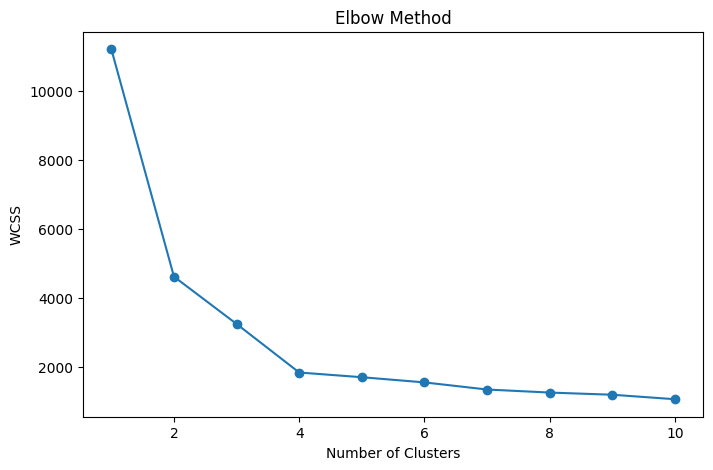

In [ ]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
silhouette_score(rfm_scaled, rfm_scaled['Cluster'])

np.float64(0.5518204618423996)

In [ ]:
RFM.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,2.690782,1.104074,6.099899
1,5.029645,0.807663,5.519385
2,2.187542,2.466662,8.358317
3,4.077684,1.517297,7.208068


In [ ]:
RFM[RFM['Cluster']==0]

,CustomerID,Recency,Frequency,Monetary,Cluster
3,12349.0,2.995732,0.693147,7.472245,0
11,12358.0,1.098612,1.098612,7.063955,0
17,12364.0,2.197225,1.609438,7.180907,0
19,12367.0,1.609438,0.693147,5.135210,0
24,12374.0,3.258097,0.693147,6.611947,0
...,...,...,...,...,...
4317,18261.0,3.784190,1.098612,5.784563,0
4323,18270.0,3.663562,1.098612,5.649502,0
4325,18273.0,1.098612,1.386294,5.323010,0
4326,18274.0,3.433987,0.693147,5.175698,0


In [ ]:
RFM[RFM['Cluster']==1]

,CustomerID,Recency,Frequency,Monetary,Cluster
4,12350.0,5.739793,0.693147,5.815324,1
6,12353.0,5.323010,0.693147,4.499810,1
7,12354.0,5.451038,0.693147,6.985087,1
8,12355.0,5.370638,0.693147,6.132096,1
14,12361.0,5.662960,0.693147,5.251750,1
...,...,...,...,...,...
4327,18276.0,3.806662,0.693147,5.819667,1
4328,18277.0,4.077537,0.693147,4.712948,1
4329,18278.0,4.317488,0.693147,5.164214,1
4330,18280.0,5.631212,0.693147,5.201806,1


In [ ]:
RFM[RFM['Cluster']==2]

,CustomerID,Recency,Frequency,Monetary,Cluster
1,12347.0,1.098612,2.079442,8.368925,2
15,12362.0,1.386294,2.397895,8.561637,2
30,12381.0,1.791759,1.791759,7.520944,2
34,12388.0,2.833213,1.945910,7.930803,2
39,12395.0,2.995732,2.564949,8.012890,2
...,...,...,...,...,...
4295,18230.0,2.302585,2.079442,7.941367,2
4304,18241.0,2.397895,2.890372,7.637278,2
4306,18245.0,2.079442,2.079442,7.850906,2
4324,18272.0,1.386294,1.945910,8.032549,2


In [ ]:
RFM[RFM['Cluster']==3]

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,5.789960,0.693147,11.253955,3
2,12348.0,4.330733,1.609438,7.494564,3
5,12352.0,3.610918,2.079442,7.418625,3
9,12356.0,3.178054,1.386294,7.941804,3
10,12357.0,3.526361,0.693147,8.733702,3
...,...,...,...,...,...
4315,18259.0,3.258097,1.386294,7.757735,3
4316,18260.0,5.159055,1.945910,7.874492,3
4319,18263.0,3.295837,1.386294,7.101808,3
4320,18265.0,4.290459,1.098612,6.687744,3


In [ ]:
cluster_map = {
    0: 'Regular Customers',
    1: 'At-risk Customers',
    2: 'Loyal Customers',
    3: 'Loyal But Inactive Customer'
}

RFM['Segment'] = RFM['Cluster'].map(cluster_map)

| Cluster       | Characteristics                                 | Customer Type            | Business Strategy                        |
| ------------- | ----------------------------------------------- | ------------------------ | ---------------------------------------- |
| **Cluster 0** | Medium Recency, Low Frequency, Medium Monetary  | Regular Customers     | Discounts, upselling, bundle offers      |
| **Cluster 1** | High Recency, Low Frequency, Low Monetary       | At-risk Customers     | Win-back campaigns, heavy discounts      |
| **Cluster 2** | Low Recency, High Frequency, Very High Monetary | Champions (Best Users) | Loyalty rewards, VIP perks, retention    |
| **Cluster 3** | High Recency, Medium Frequency, High Monetary   | Loyal but Inactive    | Re-engagement offers, personalized deals |


In [ ]:
RFM

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,5.789960,0.693147,11.253955,3,Loyal But Inactive Customer
1,12347.0,1.098612,2.079442,8.368925,2,Loyal Customers
2,12348.0,4.330733,1.609438,7.494564,3,Loyal But Inactive Customer
3,12349.0,2.995732,0.693147,7.472245,0,Regular Customers
4,12350.0,5.739793,0.693147,5.815324,1,At-risk Customers
...,...,...,...,...,...,...
4330,18280.0,5.631212,0.693147,5.201806,1,At-risk Customers
4331,18281.0,5.204007,0.693147,4.404522,1,At-risk Customers
4332,18282.0,2.197225,1.098612,5.187665,0,Regular Customers
4333,18283.0,1.609438,2.833213,7.620989,2,Loyal Customers
